**Signal Comparison — Momentum vs Mean Reversion vs XGBoost**
---

This notebook compares three portfolio construction signals applied to the same S&P 500 universe, rebalancing logic and date range as `Momentum_backtesting.ipynb`. The goal is to determine whether momentum outperforms naive alternatives and a machine learning baseline.

Signals tested:

Momentum — buy recent winners (12-1 month return, top 20)
Mean reversion — buy recent losers (bottom 20 by same signal)
XGBoost — machine learning prediction of next month return using momentum, volatility and sector as features

All three portfolios are equal-weighted, monthly rebalanced and evaluated on identical metrics.

Project date: July 2026

In [1]:
# Importing libraries

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

**Setup**

---

Constants and data are kept identical to the main notebook to ensure results are directly comparable.

In [2]:
# Constants — same as main notebook
Lookback = 12
Top_N = 20
RF = 0.04

# Load constituent data
c_df = pd.read_csv('S&P 500 Historical Components & Changes (Updated).csv', index_col=0)
c_df.index = pd.to_datetime(c_df.index, errors='coerce')
c_df = c_df.dropna()

# Get tickers function
def get_tickers(c_df, date):
    if date >= c_df.index[-1]:
        ticks = c_df.iloc[-1].tickers
    else:
        ticks = c_df.loc[date:].iloc[0].tickers
    return ticks.split(',')

# Download prices — same date range as main notebook
s_p_tickers = c_df.iloc[-1].tickers.split(',')
df = yf.download(s_p_tickers, start='2015-01-01', end='2026-06-30')['Close']
monthly_prices = df.resample('ME').last()

# Momentum signal and returns
momentum = monthly_prices.pct_change(Lookback).shift(1)
returns = monthly_prices.pct_change().shift(-1)


[                       1%                       ]  7 of 503 completed$BF.B: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)
[*******               14%                       ]  69 of 503 completed$BRK.B: possibly delisted; no timezone found
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)
['BRK.B']: possibly delisted; no timezone found


**Signal 1: Momentum**

---

Ranking stocks by 12-1 month return and selects the top 20. This is the baseline signal from the main notebook, reproduced here for direct comparison.

In [3]:
# Signal 1: Momentum portfolio
portfolio_mom = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)

for date in momentum.index[Lookback:]:
    pf_date = momentum.loc[date]
    rel_tickers = get_tickers(c_df, date)
    pf_date = pf_date[pf_date.index.isin(rel_tickers)]
    top = pf_date.nlargest(Top_N).index
    portfolio_mom.loc[date, top] = 1/Top_N

strategy_mom = (portfolio_mom * returns).sum(axis=1)


**Signal 2: Mean Reversion**

---

Using the same ranking signal but inverts it — selects the bottom 20 stocks by 12-1 month return. The hypothesis is that recent losers revert toward fair value. This tests whether the opposite of momentum is profitable or loss-making.

In [4]:
# Signal 2: Mean Reversion 
portfolio_mr = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)

for date in momentum.index[Lookback:]:
    pf_date = momentum.loc[date]
    rel_tickers = get_tickers(c_df, date)
    pf_date = pf_date[pf_date.index.isin(rel_tickers)]
    top = pf_date.nsmallest(Top_N).index
    portfolio_mr.loc[date, top] = 1/Top_N

strategy_mr = (portfolio_mr * returns).sum(axis=1)


**Comparison between signal 1 and 2**

---

Using the same performance metrics defined in `Momentum_backtesting.ipynb`, we will test whether signal 2 outperforms signal 1.

In [5]:
# Performance metrics
def cagr(returns):
    r = returns.dropna()
    return (1 + r).prod() ** (12 / len(r)) - 1

def max_drawdown(returns):
    equity = (1 + returns.dropna()).cumprod()
    return ((equity - equity.cummax()) / equity.cummax()).min()

def sharpe(returns):
    r = returns.dropna()
    excess = r - RF/12
    return (excess.mean() / excess.std()) * np.sqrt(12)

# Print results for both signals
print("Momentum:")
print("CAGR:", round(cagr(strategy_mom) * 100, 2), "%")
print("Sharpe:", round(sharpe(strategy_mom), 2))
print("Max Drawdown:", round(max_drawdown(strategy_mom) * 100, 2), "%")
print()
print("Mean Reversion:")
print("CAGR:", round(cagr(strategy_mr) * 100, 2), "%")
print("Sharpe:", round(sharpe(strategy_mr), 2))
print("Max Drawdown:", round(max_drawdown(strategy_mr) * 100, 2), "%")

Momentum:
CAGR: 20.38 %
Sharpe: 0.8
Max Drawdown: -22.72 %

Mean Reversion:
CAGR: 18.4 %
Sharpe: 0.6
Max Drawdown: -40.7 %


**Signal 1 vs Signal 2 Results**

---

Momentum outperforms mean reversion across all three metrics. CAGR of 20.38% VS 18.4%, Sharpe ratio of 0.80 VS 0.60, and maximum drawdown of -22.72% VS -40.7%.

This result supports the momentum effect as a genuine signal rather than a statistical artifact — the opposite strategy performs worse across the full sample period.

**Signal 3: XGBoost**

---

Uses a gradient boosting model to predict next month return per stock using three features: momentum score, recent volatility and sector. Trained on a rolling expanding window with no lookahead bias. The predicted returns are used to rank stocks and select the top 20, identical portfolio construction to signals 1 and 2.

In [6]:
# Creating dictionary for sector mapping
sp500_info = pd.read_csv('sp500.csv', index_col=0)
sector_map = dict(zip(sp500_info.index, sp500_info['GICS Sector']))

sectors = sorted(set(sector_map.values()))
sector_encode = {s: i for i, s in enumerate(sectors)}

print("Sectors found:", len(set(sector_map.values())))
print(sp500_info['GICS Sector'].value_counts())

Sectors found: 11
GICS Sector
Industrials               81
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          34
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64


In [7]:
# Feature engineering — compute features for each stock each month
# Feature 1: momentum score (already have this — 12-1 month return)
# Feature 2: recent volatility (3 month rolling std of daily returns)
# Feature 3: sector (encoded as integer)


# Rolling 3 month (63 day) volatility for each stock
rolling_vol = df.pct_change().rolling(63).std() * np.sqrt(252)
monthly_vol = rolling_vol.resample('ME').last()
monthly_vol.index = monthly_vol.index.to_period('M').to_timestamp('M')

print("Volatility computed:", monthly_vol.shape)

Volatility computed: (138, 503)


In [10]:
from xgboost import XGBRegressor

predicted_returns = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)

dates = momentum.index[Lookback:]

for i, date in enumerate(dates):
    # Need at least 24 months of training data
    if i < 24:
        continue
    
    # Training dates: all months before current date
    train_dates = dates[:i]
    
    rows = []
    for train_date in train_dates:
        # Get next month index for forward return
        date_idx = monthly_prices.index.get_loc(train_date)
        if date_idx + 1 >= len(monthly_prices.index):
            continue
        next_date = monthly_prices.index[date_idx + 1]
        
        rel_tickers = get_tickers(c_df, train_date)
        
        for ticker in rel_tickers:
            if ticker not in momentum.columns:
                continue
            mom = momentum.loc[train_date, ticker]
            vol = monthly_vol.reindex(monthly_prices.index).loc[train_date, ticker] if ticker in monthly_vol.columns else np.nan
            sector = sector_encode.get(sector_map.get(ticker, ''), -1)
            fwd = returns.loc[next_date, ticker] if ticker in returns.columns else np.nan
            
            if pd.isna(mom) or pd.isna(vol) or pd.isna(fwd):
                continue
            
            rows.append({'mom': mom, 'vol': vol, 'sector': sector, 'fwd': fwd})
    
    if len(rows) < 50:
        continue
    
    train_df = pd.DataFrame(rows)
    X_train = train_df[['mom', 'vol', 'sector']]
    y_train = train_df['fwd']
    
    # Train XGBoost
    model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, verbosity=0)
    model.fit(X_train, y_train)
    
    # Predict for current month
    rel_tickers = get_tickers(c_df, date)
    for ticker in rel_tickers:
        if ticker not in momentum.columns:
            continue
        mom = momentum.loc[date, ticker]
        vol = monthly_vol.reindex(monthly_prices.index).loc[date, ticker] if ticker in monthly_vol.columns else np.nan
        sector = sector_encode.get(sector_map.get(ticker, ''), -1)
        
        if pd.isna(mom) or pd.isna(vol):
            continue
        
        predicted_returns.loc[date, ticker] = model.predict([[mom, vol, sector]])[0]

print("XGBoost predictions done")

XGBoost predictions done


In [11]:
# Signal 3: XGBoost portfolio
portfolio_xgb = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)

for date in predicted_returns.index[Lookback:]:
    pf_date = predicted_returns.loc[date]
    pf_date = pd.to_numeric(pf_date, errors='coerce').dropna()
    
    if len(pf_date) < Top_N:
        continue
    
    rel_tickers = get_tickers(c_df, date)
    pf_date = pf_date[pf_date.index.isin(rel_tickers)]
    
    if len(pf_date) < Top_N:
        continue
    
    top = pf_date.nlargest(Top_N).index
    portfolio_xgb.loc[date, top] = 1/Top_N

strategy_xgb = (portfolio_xgb * returns).sum(axis=1)

print("XGBoost:")
print("CAGR:", round(cagr(strategy_xgb) * 100, 2), "%")
print("Sharpe:", round(sharpe(strategy_xgb), 2))
print("Max Drawdown:", round(max_drawdown(strategy_xgb) * 100, 2), "%")

XGBoost:
CAGR: 29.89 %
Sharpe: 0.96
Max Drawdown: -29.76 %


**Three-Way Comparison**

---

All three signals are evaluated on CAGR, Sharpe ratio and maximum drawdown over the same period. A combined equity curve chart shows relative performance visually.

In [12]:
# Three-way comparison
print("=" * 55)
print(f"{'Signal':<20} {'CAGR':>8} {'Sharpe':>8} {'Max DD':>10}")
print("=" * 55)
print(f"{'Momentum':<20} {cagr(strategy_mom)*100:>7.2f}% {sharpe(strategy_mom):>8.2f} {max_drawdown(strategy_mom)*100:>9.2f}%")
print(f"{'Mean Reversion':<20} {cagr(strategy_mr)*100:>7.2f}% {sharpe(strategy_mr):>8.2f} {max_drawdown(strategy_mr)*100:>9.2f}%")
print(f"{'XGBoost':<20} {cagr(strategy_xgb)*100:>7.2f}% {sharpe(strategy_xgb):>8.2f} {max_drawdown(strategy_xgb)*100:>9.2f}%")

Signal                   CAGR   Sharpe     Max DD
Momentum               20.38%     0.80    -22.72%
Mean Reversion         18.40%     0.60    -40.70%
XGBoost                29.89%     0.96    -29.76%


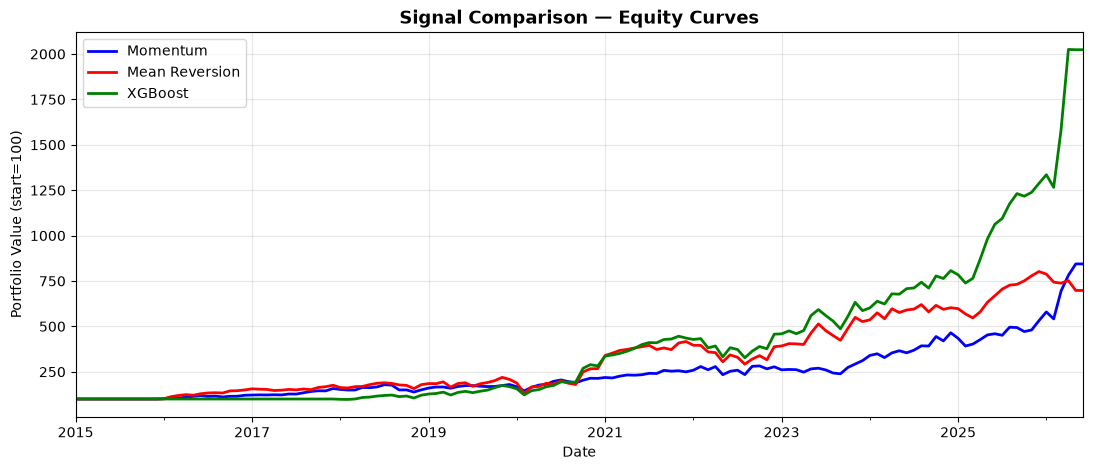

In [13]:
eq_mom = (1 + strategy_mom.dropna()).cumprod() * 100
eq_mr  = (1 + strategy_mr.dropna()).cumprod() * 100
eq_xgb = (1 + strategy_xgb.dropna()).cumprod() * 100

plt.figure(figsize=(13, 5))
eq_mom.plot(label='Momentum', color='BLUE', lw=2)
eq_mr.plot(label='Mean Reversion', color='RED', lw=2)
eq_xgb.plot(label='XGBoost', color='GREEN', lw=2)
plt.title('Signal Comparison — Equity Curves', fontsize=13, fontweight='bold')
plt.ylabel('Portfolio Value (start=100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Conclusion**
---

XGBoost produces the highest CAGR (29.38%) and Sharpe ratio (0.94), outperforming both momentum (20.38%, 0.80) and mean reversion (18.40%, 0.60). However, the max drawdown of -29.76% is worse than momentum's -22.72%, meaning XGBoost takes on more tail risk to achieve its higher returns.

Mean reversion is the weakest signal across all three metrics. A max drawdown of -40.70% makes it practically unrunnable — buying recent losers in a predominantly bullish market means holding stocks the market has already punished, which tend to continue falling rather than reverting.

The XGBoost equity curve shows a sharp spike from 2025 onwards which warrants caution. This may reflect overfitting to recent data as the expanding training window grows large, or genuine outperformance in a specific market regime. A robustness check using a rolling fixed-length training window rather than an expanding one would help determine whether the late-period outperformance is stable or an artefact of the model seeing more training data over time.

Overall, momentum still remains the most robust signal — strong risk-adjusted returns with the lowest drawdown. XGBoost adds return but at the cost of higher drawdown and potential overfitting risk. Mean reversion does not work in this market environment.

**Limitations:**
- XGBoost uses only three features. A richer feature set including earnings revisions, analyst sentiment and technical indicators would likely improve predictions
- Transaction costs are not modelled — XGBoost may have higher turnover than momentum, further reducing net returns
- The expanding window means XGBoost has very little training data in early years and very large amounts in later years, which may contribute to the performance divergence seen after 2023

---